In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for cleaner plots
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv(
    r'D:\Projects\CREDIT CARD FRAUD DETECTION SYSTEM\fraud-detection\data\creditcard.csv'
)

print(f"Dataset Shape: {df.shape}")

print("\nMissing Values:")
print(df.isnull().sum().max())

display(df.head())

Dataset Shape: (284807, 31)

Missing Values:
0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class Distribution Counts:
Class
0    284315
1       492
Name: count, dtype: int64

Class Distribution Percentages:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


C:\Users\Chinmay Patil\AppData\Local\Temp\ipykernel_6636\1754829199.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Class', data=df, palette='Set2')


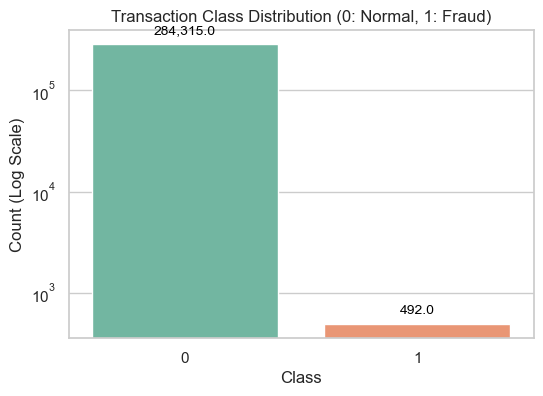

In [6]:
# Class counts and percentages
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print("Class Distribution Counts:")
print(class_counts)

print("\nClass Distribution Percentages:")
print(class_pct)

# Plot class distribution
plt.figure(figsize=(6, 4))

ax = sns.countplot(x='Class', data=df, palette='Set2')

plt.title("Transaction Class Distribution (0: Normal, 1: Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")

# Add count annotations on top of bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black',
        xytext=(0, 5),
        textcoords='offset points'
    )

# Log scale because normal transactions greatly outnumber fraud
plt.yscale('log')
plt.ylabel("Count (Log Scale)")

plt.show()

--- Non-Fraud (Class 0) Amount Stats ---
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

--- Fraud (Class 1) Amount Stats ---
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


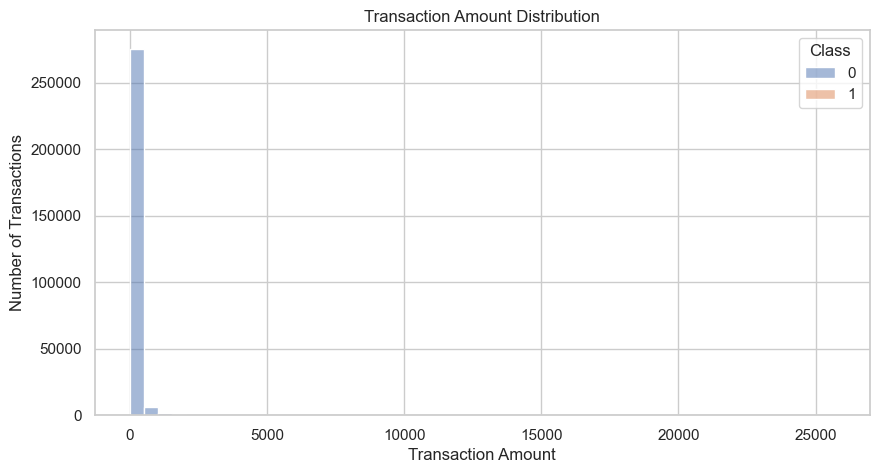

In [9]:
# Summary statistics of Amount for Non-Fraud transactions
print("--- Non-Fraud (Class 0) Amount Stats ---")
print(df[df['Class'] == 0]['Amount'].describe())

# Summary statistics of Amount for Fraud transactions
print("\n--- Fraud (Class 1) Amount Stats ---")
print(df[df['Class'] == 1]['Amount'].describe())


# Plot Amount distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='Amount',
    hue='Class',
    bins=50
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.show()



In [11]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# 1. Load the dataset using your verified path
data_path = r'D:\Projects\CREDIT CARD FRAUD DETECTION SYSTEM\fraud-detection\data\creditcard.csv'
print(f"Loading dataset from: {data_path}")
df = pd.read_csv(data_path)

# 2. Separate features and target
X = df.drop(columns=['Class'])
y = df['Class']

# 3. Stratified split to preserve the 0.17% class imbalance ratio in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Initialize scaler
scaler = StandardScaler()

# 5. Fit ONLY on training data to prevent data leakage, then transform both
cols_to_scale = ['Time', 'Amount']
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# 6. Ensure models directory exists and save the fitted scaler
os.makedirs('../models', exist_ok=True) # Use 'models' if running from root, '../models' if inside notebooks/
scaler_path = '../models/scaler.joblib'
joblib.dump(scaler, scaler_path)

print(f"Preprocessing complete!")
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")
print(f"Scaler saved successfully to {scaler_path}")

Loading dataset from: D:\Projects\CREDIT CARD FRAUD DETECTION SYSTEM\fraud-detection\data\creditcard.csv
Preprocessing complete!
Training features shape: (227845, 30)
Testing features shape: (56962, 30)
Scaler saved successfully to ../models/scaler.joblib



--- Training Logistic Regression (Balanced) ---
PR-AUC (Average Precision): 0.7159
Confusion Matrix:
[[55478  1386]
 [    8    90]]
Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0610    0.9184    0.1144        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5510     56962
weighted avg     0.9982    0.9755    0.9861     56962


--- Training Random Forest (Balanced Subsample) ---
PR-AUC (Average Precision): 0.8597
Confusion Matrix:
[[56861     3]
 [   26    72]]
Classification Report:
              precision    recall  f1-score   support

           0     0.9995    0.9999    0.9997     56864
           1     0.9600    0.7347    0.8324        98

    accuracy                         0.9995     56962
   macro avg     0.9798    0.8673    0.9161     56962
weighted avg     0.9995    0.9995    0.9995     56962



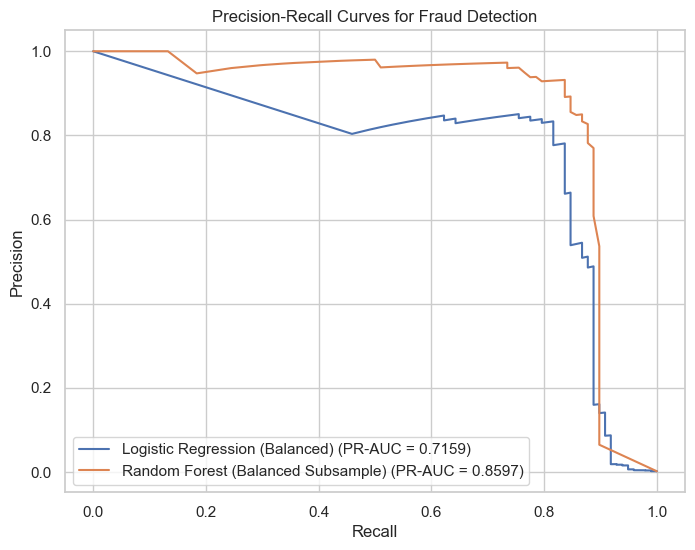


Best Model (Random Forest (Balanced Subsample)) saved successfully to ../models/model.joblib with PR-AUC: 0.8597


In [12]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc, average_precision_score
import joblib
import os

# Dictionary to store trained models and their PR-AUC scores
models_to_train = {
    "Logistic Regression (Balanced)": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest (Balanced Subsample)": RandomForestClassifier(class_weight='balanced_subsample', n_estimators=100, random_state=42, n_jobs=-1)
}

best_model_name = None
best_model = None
best_pr_auc = 0.0

plt.figure(figsize=(8, 6))

for name, model in models_to_train.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train_scaled, y_train)
    
    # Predict probabilities (probability of class 1 / fraud)
    y_scores = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = model.predict(X_test_scaled)
    
    # Metrics
    precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
    pr_auc = average_precision_score(y_test, y_scores)
    
    print(f"PR-AUC (Average Precision): {pr_auc:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    
    # Plot PR Curve
    plt.plot(recall, precision, label=f'{name} (PR-AUC = {pr_auc:.4f})')
    
    # Track the best model based on PR-AUC
    if pr_auc > best_pr_auc:
        best_pr_auc = pr_auc
        best_model = model
        best_model_name = name

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Fraud Detection')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# Save the best model
os.makedirs('../models', exist_ok=True)
model_path = '../models/model.joblib'
joblib.dump(best_model, model_path)
print(f"\nBest Model ({best_model_name}) saved successfully to {model_path} with PR-AUC: {best_pr_auc:.4f}")

In [13]:
import joblib
import os
import pandas as pd
import numpy as np

# 1. Define paths (adjust paths if running from root vs notebooks folder)
model_path = '../models/model.joblib'
scaler_path = '../models/scaler.joblib'

# Load the saved model and scaler
print("Loading trained model and scaler...")
model = joblib.load(model_path)
scaler = joblib.load(scaler_path)

def predict_transaction(transaction_data):
    """
    Takes a dictionary or DataFrame of transaction features,
    scales Time and Amount, and returns fraud prediction & probability.
    """
    # Ensure input is a DataFrame
    if isinstance(transaction_data, dict):
        df_new = pd.DataFrame([transaction_data])
    else:
        df_new = transaction_data.copy()
        
    # Scale 'Time' and 'Amount' using the fitted production scaler
    cols_to_scale = ['Time', 'Amount']
    df_new[cols_to_scale] = scaler.transform(df_new[cols_to_scale])
    
    # Predict class (0: Normal, 1: Fraud) and probability
    prediction = model.predict(df_new)[0]
    fraud_prob = model.predict_proba(df_new)[0, 1]
    
    return {
        'prediction': int(prediction),
        'fraud_probability': float(fraud_prob),
        'status': 'FRAUDULENT' if prediction == 1 else 'LEGITIMATE'
    }

# 2. Test the prediction function using a sample row from your test set
if 'X_test_scaled' in globals():
    sample_row = X_test_scaled.iloc[0].to_dict()
    result = predict_transaction(sample_row)
    print("\n--- Test Prediction Result ---")
    print(f"Status: {result['status']}")
    print(f"Fraud Probability: {result['fraud_probability']:.4f}")
else:
    print("\nPrediction function ready! (Pass a transaction dictionary to test)")

Loading trained model and scaler...

--- Test Prediction Result ---
Status: LEGITIMATE
Fraud Probability: 0.0000
